In [1]:
from myutils import cache, clean_all_cache

from src import *
from glob import glob

In [2]:
# clean_all_cache()

done


In [2]:
@cache
def read_est(A):
    file_tree = [
        f'__estimates__/0noise/spade_{A}px/*',
        f'__estimates__/0noise/di_{A}px/*'
    ]

    spade_x, spade_y = [], []
    di_x, di_y = [], []

    for file in file_tree:
        for f in glob(file):
            c = LoadEstimates(f) 
            if c.metadata.measurement == 'DI':
                di_x.append(c.metadata.ground_truth)
                di_y.append(c.estimates_a.var(ddof=0) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))
            elif c.metadata.measurement == 'SPADE':
                spade_x.append(c.metadata.ground_truth)
                spade_y.append(c.estimates_a.var(ddof=0) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))

    return np.array(di_x), np.array(di_y), np.array(spade_x), np.array(spade_y)

cache hit: reading result from cache file
cache hit: reading result from cache file
cache hit: reading result from cache file
cache hit: reading result from cache file


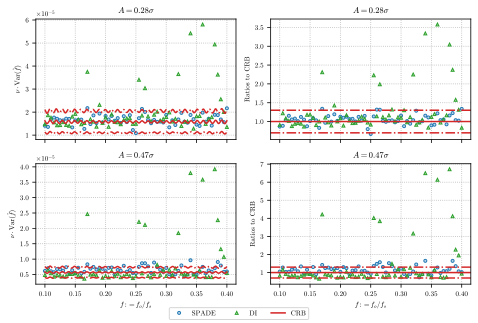

In [18]:
width = 8.5 * 2

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ([ax1, ax2],[ax3, ax4]) = plt.subplots(2, 2, figsize=(width / 2.54, width / 2.54 / 3 * 2), sharex=True)

for ax in (ax1, ax3):
    A = 3 if ax == ax1 else 5

    x_axis = np.linspace(0.1, 0.4, 1000)

    crb = (1 / FisherInformation([A * DMD.PIXEL_SIZE / 2], x_axis))[0]

    di_x, di_y, spade_x, spade_y = read_est(A)

    line1, = ax.plot(spade_x, spade_y, 
                    marker='o', linestyle='', markersize=3,
                    markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

    line2, = ax.plot(di_x, di_y,
                    marker='^', linestyle='', markersize=3,
                    markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')

    line3, = ax.plot(x_axis, crb, 'C3')
    ax.plot(x_axis, 0.7 * crb, 'C3-.')
    ax.plot(x_axis, 1.3 * crb, 'C3-.')

    ax.grid(True, linestyle=':')

    ax.set_ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')
    ax.set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')


for ax in (ax2, ax4):
    A = 3 if ax == ax2 else 5

    crb = lambda f: (1 / FisherInformation([A * DMD.PIXEL_SIZE / 2], f))[0]

    di_x, di_y, spade_x, spade_y = read_est(A)

    ax.plot(spade_x, spade_y / crb(spade_x), 
            marker='o', linestyle='', markersize=3,
            markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

    ax.plot(di_x, di_y / crb(di_x),
            marker='^', linestyle='', markersize=3,
            markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')

    ax.grid(True, linestyle=':')

    ax.set_ylabel(f'Ratios to CRB')
    ax.set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')

    ax.axhline(1, color='C3')
    ax.axhline(0.7, color='C3', linestyle='-.')
    ax.axhline(1.3, color='C3', linestyle='-.')

ax3.set_xlabel(r'$f := f_o / f_s$')
ax4.set_xlabel(r'$f := f_o / f_s$')

for ax in (ax1, ax2, ax3, ax4):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))


fig.legend([line1, line2, line3], ['SPADE', 'DI', 'CRB'], ncol=3, loc='lower center')
plt.tight_layout()
plt.savefig('0noise.pdf')
plt.show()

In [4]:
di_x, spade_x = [], []
di_y, spade_y = [], []

spade_pn, di_pn = [LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d0.npz').photons.mean() for m in ('spade', 'di')]

for duty in np.arange(0, 101, 2):
    for m in ('spade', 'di'):
        c = LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d{duty}.npz')
        if m == 'spade':
            spade_x.append(qCMOS.convert2photons(c.background.mean()))
            spade_y.append(c.estimates_a.var(ddof=1) * spade_pn)

        if m == 'di':
            di_x.append(qCMOS.convert2photons(c.background.mean()))
            di_y.append(c.estimates_a.var(ddof=1) * di_pn)

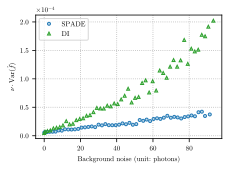

In [17]:
width = 8.5

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ax = plt.subplots(1, 1, figsize=(width / 2.54, width / 2.54 / 3 * 2))
ax.plot(spade_x, spade_y, linestyle='', linewidth=1,
        marker='o', markersize=3,
        markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

ax.plot(di_x, di_y, linestyle='', linewidth=1,
        marker='^', markersize=3,
        markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')

ax.legend(labels=['SPADE', 'DI'])
ax.grid(True, linestyle=':')


# axins = inset_axes(ax, width='20%', height='20%',loc='lower left',
#                    bbox_to_anchor=(0.05, 0.31, 1, 1),
#                    bbox_transform=ax.transAxes)


# axins.plot(spade_x[:3], spade_y[:3], color='#1f77b44d', linestyle='--', linewidth=1,
#            marker='o', markersize=2,
#            markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

# axins.plot(di_x[:3], di_y[:3], color='#2ca02c4d', linestyle='--', linewidth=1,
#            marker='^', markersize=2,
#            markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')


# mark_inset(ax, axins, loc1=3, loc2=4)

ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))

ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))


ax.set_xlabel('Background noise (unit: photons)')
ax.set_ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')

plt.savefig('noisy.pdf')
plt.show()

In [ ]:
# data = []

# for i, d in enumerate([0, 2, 4, 6]):
#     raw = np.load(rf'H:\noisy\20241112\di_0.2_raw_{d}.npy')

#     pn = np.round(qCMOS.convert2photons(np.ravel(raw[..., 5, 5].astype(float))))
#     bins = int(pn.max() - pn.min())
#     lam = pn.mean()

#     data.append([pn, bins, lam])

# np.save('bg_noise_data.npy', np.array(data, dtype=object))

In [15]:
6* 2.54

15.24

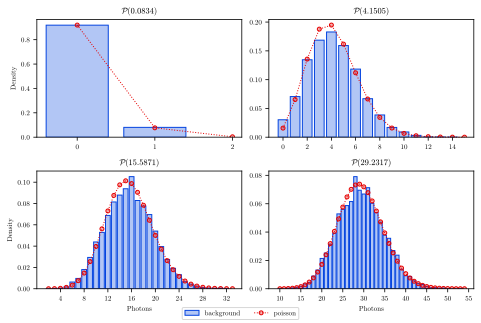

In [29]:
from scipy.stats import poisson

width = 8.5 * 2

fig, ax = plt.subplots(2, 2, figsize=(width / 2.54, width / 2.54 / 3 * 2))
ax = np.ravel(ax)

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'


for i, d in enumerate([0, 2, 4, 6]):

    data = np.load('bg_noise_data.npy', allow_pickle=True)

    pn = data[i][0]
    bins = data[i][1]
    lam = data[i][2]

    k = np.arange(pn.min(), pn.max()+1)
    line1 = ax[i].plot(k, poisson(lam).pmf(k), color='#e50000', linestyle=':', linewidth=1,
                        marker='o', markersize=4,
                        markeredgecolor='#e50000', markerfacecolor='#e500004d')

    line2 = ax[i].hist(pn, bins=bins, histtype='bar', rwidth=0.8, align='left', color='#0343df4d', edgecolor='#0343df', density=True)
    ax[i].set_title(r'$\mathcal{P}'+f'({lam})$')

    ax[i].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    # ax[i].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))

    # ax[i].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

[ax[i].set_xlabel('Photons') for i in (2, 3)]
[ax[i].set_ylabel('Density') for i in (0, 2)]

fig.legend([line2[2], line1[0]], ['background', 'poisson'], ncol=2, loc='lower center')
plt.tight_layout()
plt.savefig('poisson noise.pdf')
plt.show()

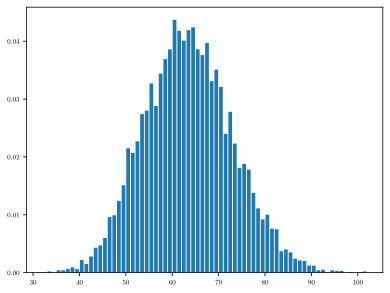

In [39]:
from myutils import *

c = LoadEstimates(r'__estimates__\0noise\spade_5px\spade_5px_f0.1_d0.npz')
hist(np.ravel(np.round(c.photons)), bins=70, rwidth=0.8, histtype='bar')

In [40]:
np.ravel(np.round(c.photons)).mean()

63.0041